In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
trades = pd.read_csv("historical_data.csv")

sentiment = pd.read_csv("fear_greed_index.csv")
trades.head()

trades.info()

trades.describe()
trades.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

### 1. Check Sentiment Distribution

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

# Convert dates
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['Date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

# Merge
merged = pd.merge(
    trades,
    sentiment[['Date','classification','value']],
    on='Date',
    how='inner'
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (211218, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80


In [ ]:
merged['classification'].value_counts()

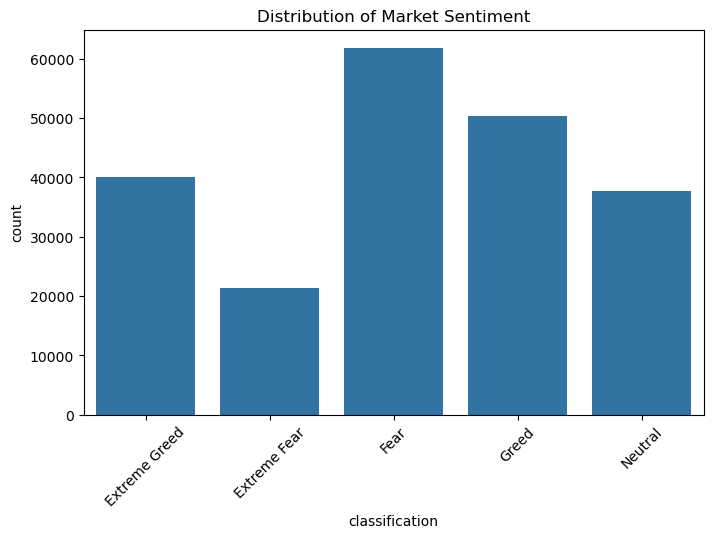

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.title("Distribution of Market Sentiment")

plt.xticks(rotation=45)

plt.show()

### 2. Profitability by Sentiment

In [20]:
profit_analysis = merged.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count','mean','median','sum']
)

print(profit_analysis)

                count       mean  median           sum
classification                                        
Extreme Fear    21400  34.537862     0.0  7.391102e+05
Extreme Greed   39992  67.892861     0.0  2.715171e+06
Fear            61837  54.290400     0.0  3.357155e+06
Greed           50303  42.743559     0.0  2.150129e+06
Neutral         37686  34.307718     0.0  1.292921e+06


### Plot

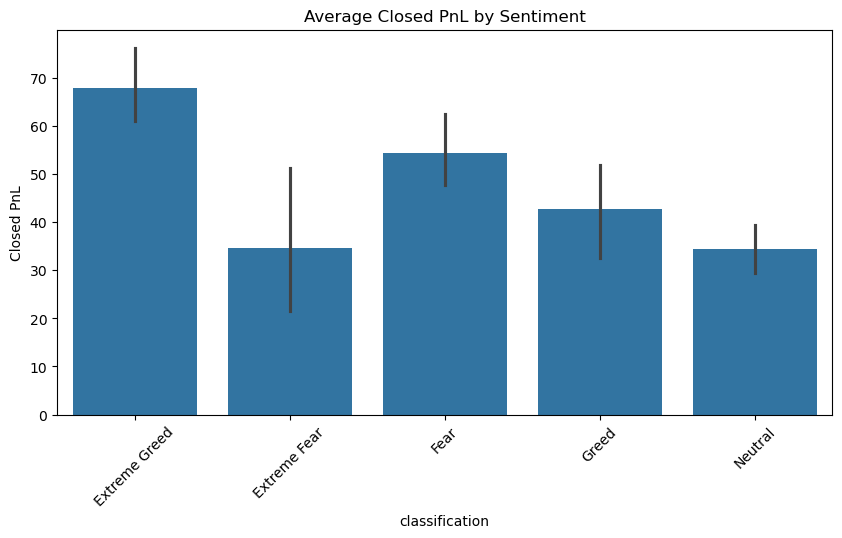

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("Average Closed PnL by Sentiment")

plt.xticks(rotation=45)

plt.show()

### 3. Trading Volume by Sentiment

In [22]:
volume_analysis = merged.groupby(
    'classification'
)['Size USD'].mean()

print(volume_analysis)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


### Plot

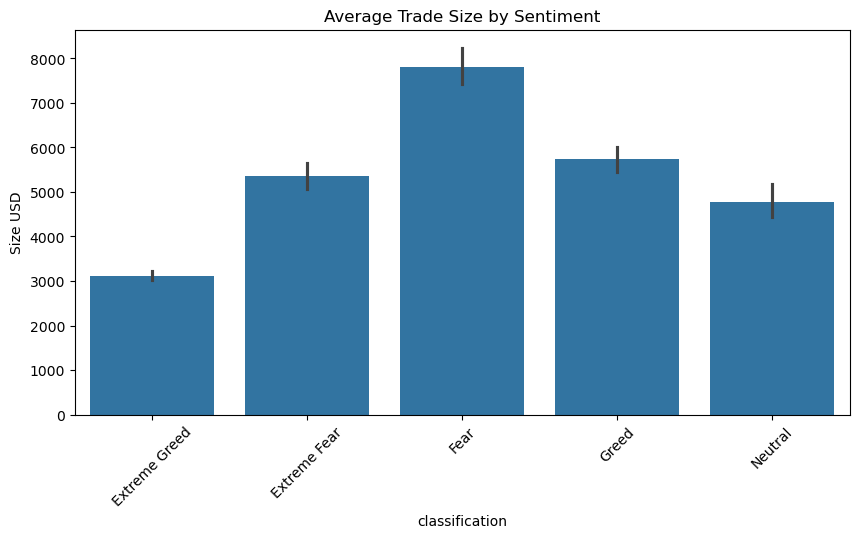

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Size USD'
)

plt.title("Average Trade Size by Sentiment")

plt.xticks(rotation=45)

plt.show()

### 4.Buy vs Sell Behaviour

In [24]:
buy_sell = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


### Plot

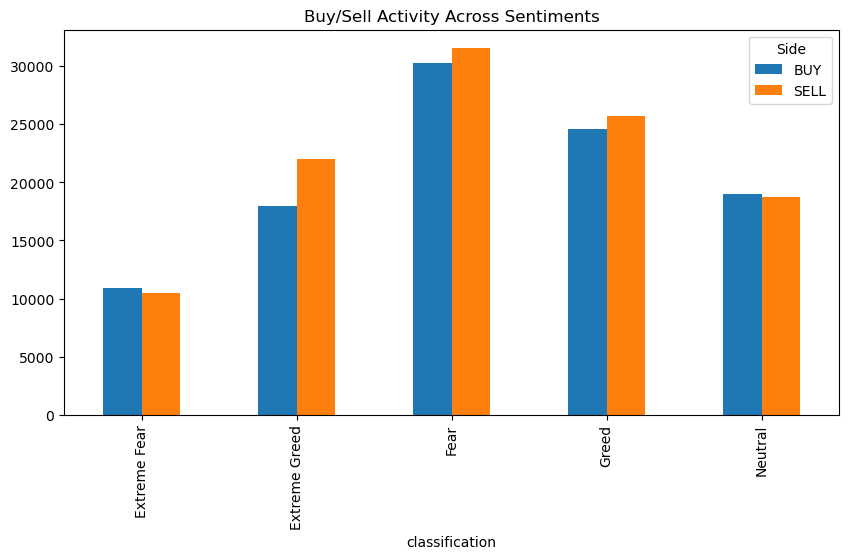

In [25]:
buy_sell.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Buy/Sell Activity Across Sentiments")

plt.show()

### 5.Winning Trade Percentage

In [27]:
merged['Profit_Flag'] = (
    merged['Closed PnL'] > 0
).astype(int)

In [28]:
win_rate = merged.groupby(
    'classification'
)['Profit_Flag'].mean()*100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Profit_Flag, dtype: float64


### Plot

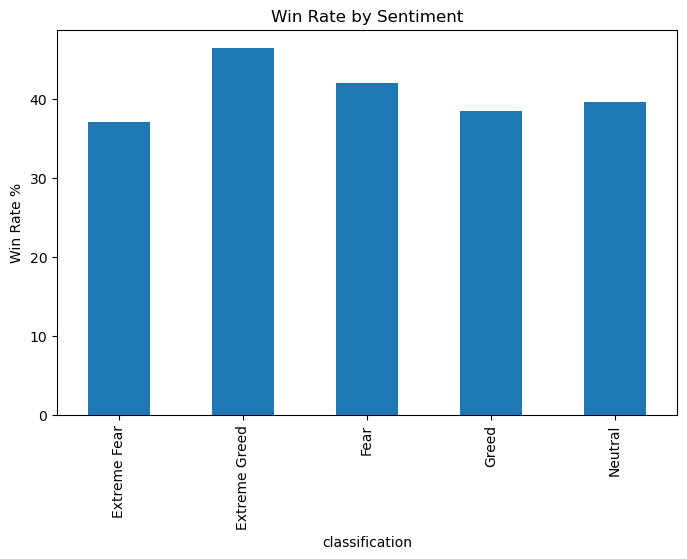

In [29]:
win_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Win Rate %")

plt.title("Win Rate by Sentiment")

plt.show()

### 6. PnL Distribution (Interviewers Love This)

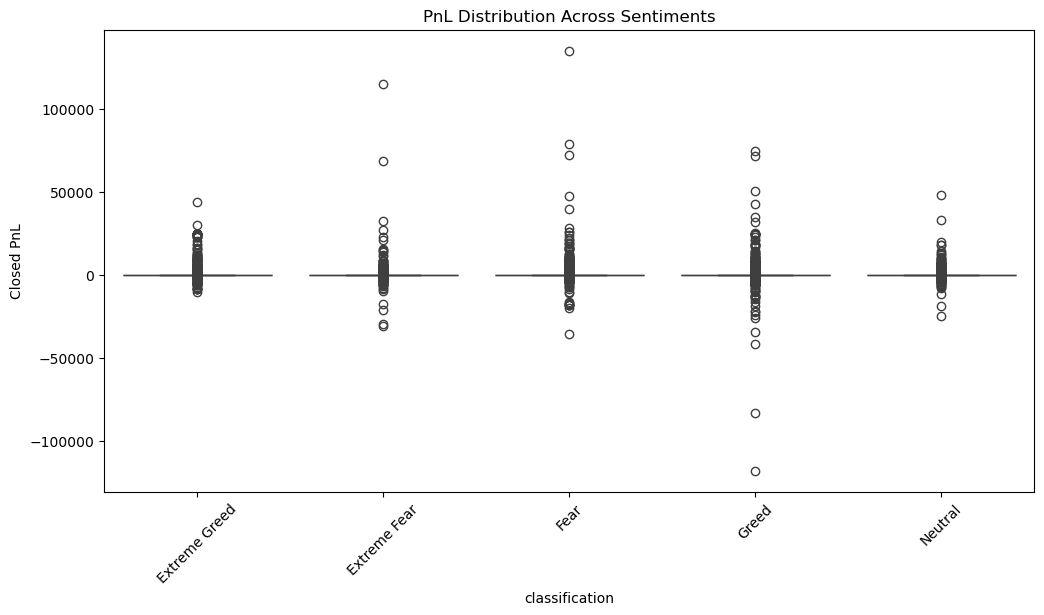

In [30]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=45)

plt.title("PnL Distribution Across Sentiments")

plt.show()

### 7.Top Traders

In [31]:
top_traders = (
    merged.groupby('Account')
    ['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64


### Plot

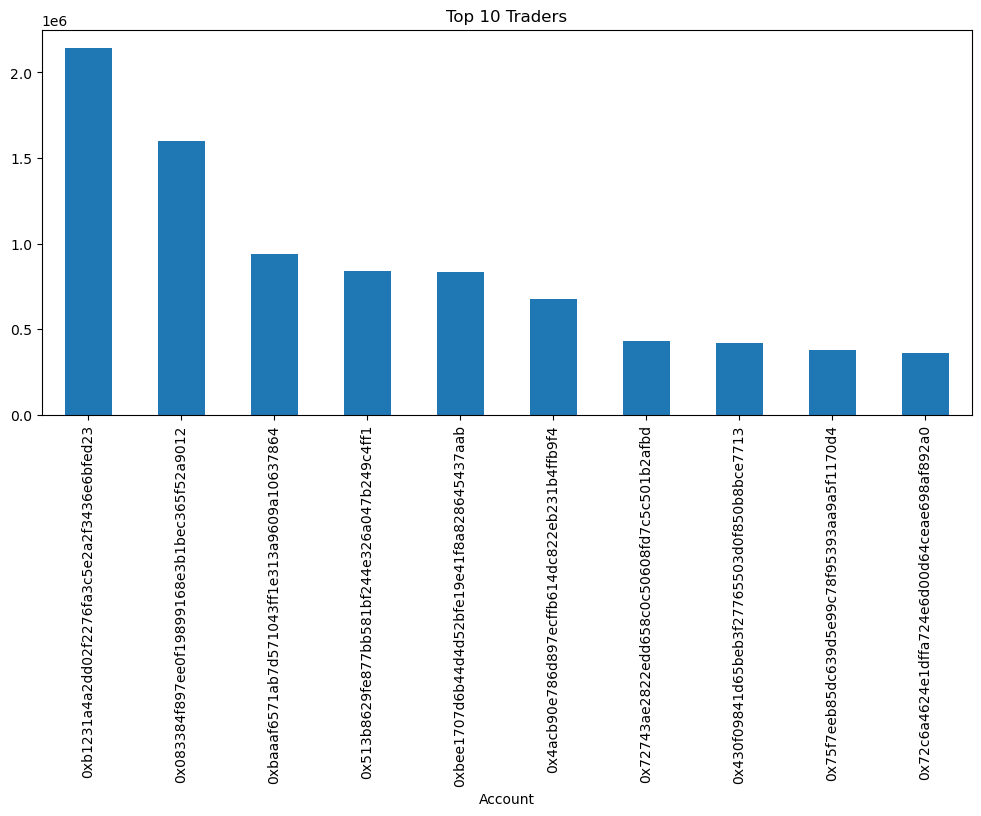

In [32]:
top_traders.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Traders")

plt.show()

### 8.Correlation Heatmap

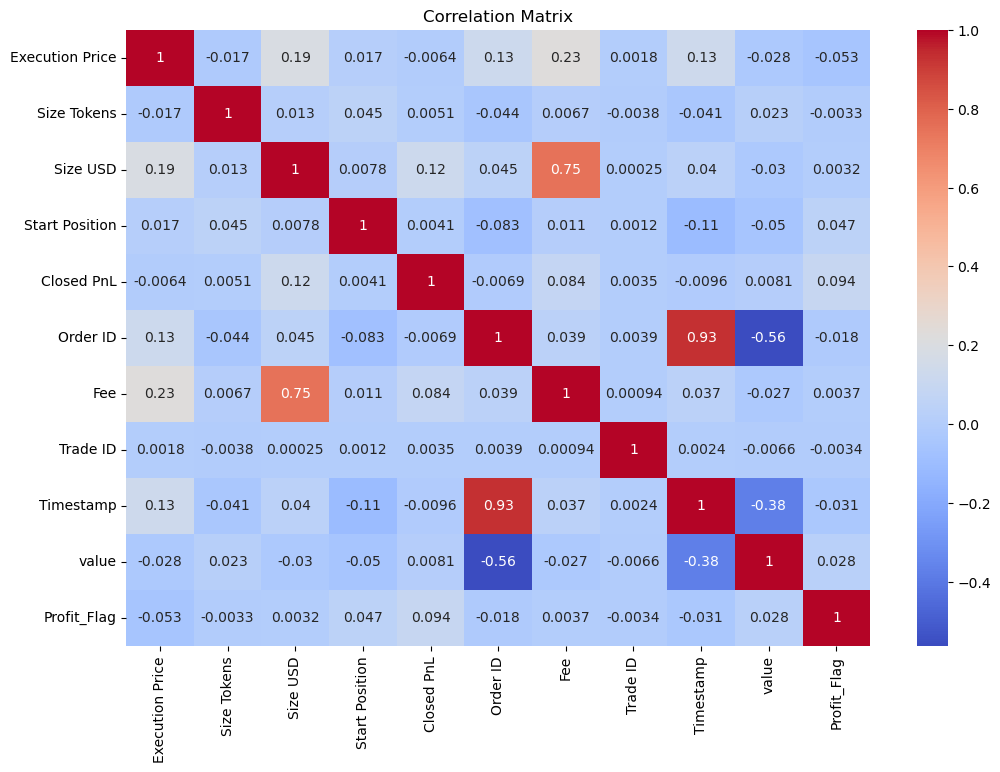

In [33]:
numeric_cols = merged.select_dtypes(
    include='number'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [34]:
profit_analysis

,count,mean,median,sum
classification,,,,
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Neutral,37686,34.307718,0.0,1.292921e+06


In [35]:
volume_analysis

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [36]:
win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Profit_Flag, dtype: float64

### Chart 1: Sentiment Distribution

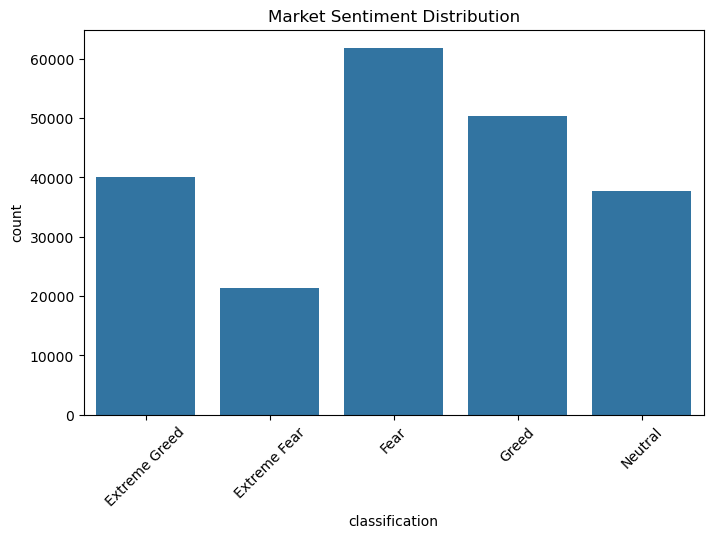

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.xticks(rotation=45)
plt.title("Market Sentiment Distribution")

plt.show()

### Chart 2: PnL Distribution

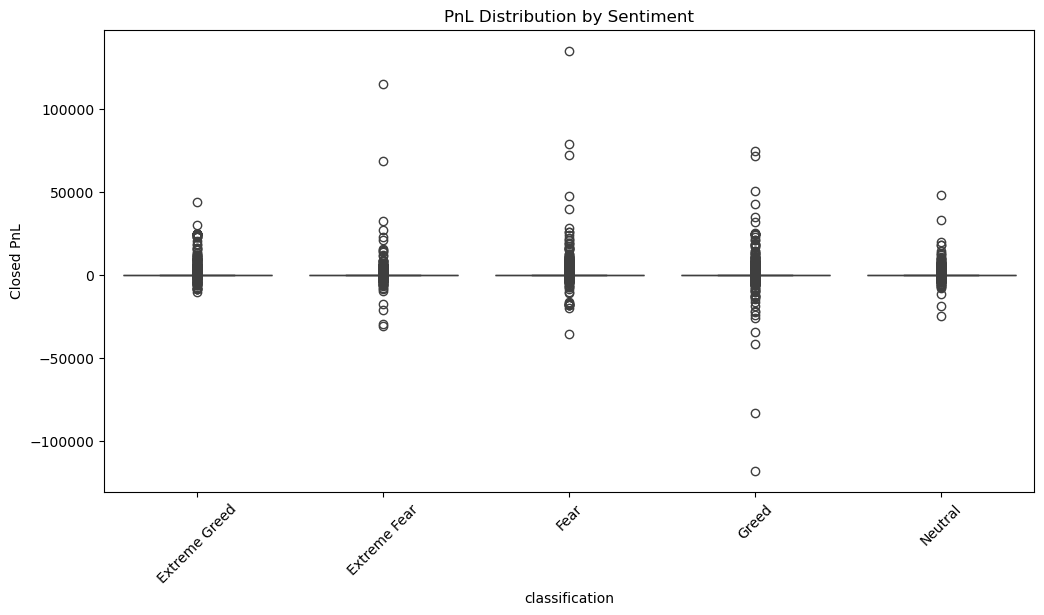

In [38]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=45)

plt.title("PnL Distribution by Sentiment")

plt.show()

### Chart 3: Top 10 Traders

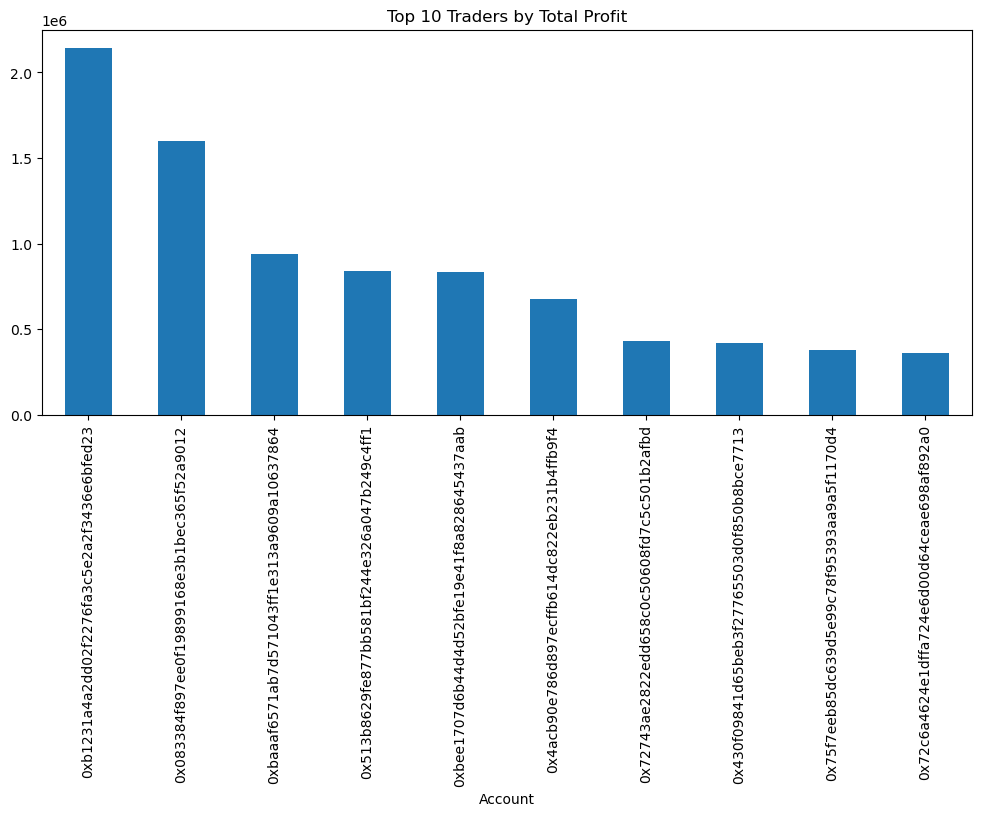

In [39]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Traders by Total Profit")

plt.show()